In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


In [2]:
PROCESSED_DIR = Path("../data/processed")

facility_distance = pd.read_csv(PROCESSED_DIR / "facility_distance_time.csv")
pop_corrected = pd.read_csv(PROCESSED_DIR / "pop_corrected.csv")

categories = [
    "restaurant", "shopping", "healthcare", "tourist", "culture",
    "sports", "transportation", "life", "government", "avg_distance",
]

# Merge travel times with corrected population counts; inner join keeps only hexagons present in both processed inputs.
df = facility_distance.merge(pop_corrected, on="Id", how="inner")
print(f"Merged grid count: {len(df)}")


Merged grid count: 19727


# Travel Time Analysis


### 2.0 Notebook Setup and Inputs
This notebook compares simple and population-weighted travel-time summaries. It reads processed travel times and corrected population counts from notebook 01 and produces weighted-comparison tables for validation and supplementary analysis.


## Population-Weighted Accessibility Comparison


### 2.1 Population-Weighted Accessibility Comparison
This section runs the shared weighting script to compare unweighted grid averages with population-weighted travel times. The output quantifies whether sparsely populated hexagons materially affect category-level accessibility conclusions.


Merged grid count: 19727

======= Comparison Results =======
                Elder_Simple_Mean(min)  Elder_PW_Mean(min)  Elder_Diff(min)  Elder_Diff(%)  Elder_15min_Coverage  Labor_Simple_Mean(min)  Labor_PW_Mean(min)  Labor_Diff(min)  Labor_Diff(%)  Labor_15min_Coverage
Category                                                                                                                                                                                                          
restaurant                       60.41               13.37           -47.04          -77.9                0.7618                   32.60                6.98           -25.62          -78.6                0.9051
shopping                         68.41               15.29           -53.12          -77.6                0.7123                   36.91                8.02           -28.89          -78.3                0.8943
healthcare                       80.76               18.51           -62.25          -77.1     

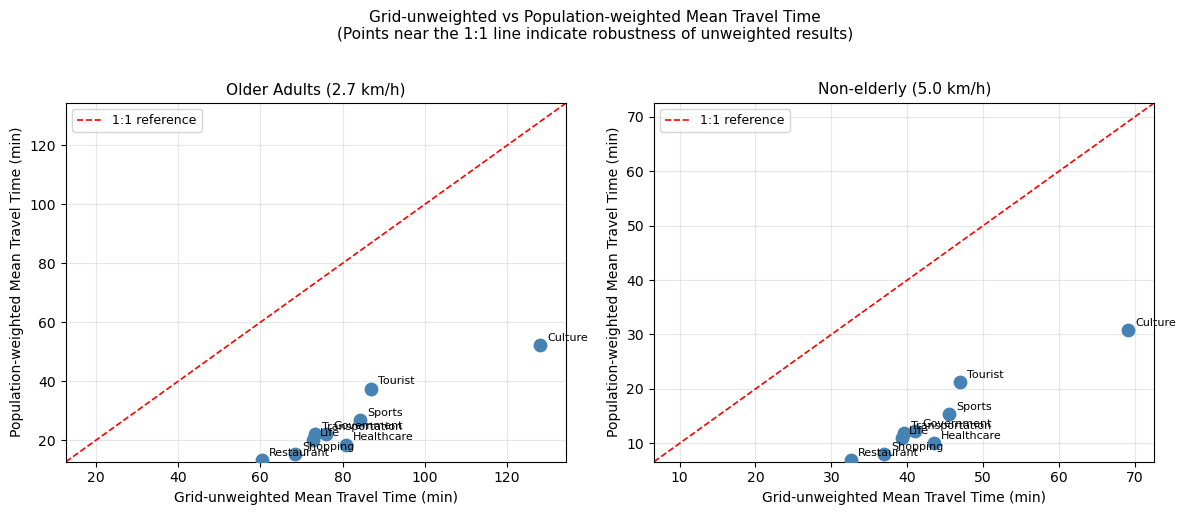


Figure saved to /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/weighted_vs_unweighted_comparison.png
Supplementary table saved to /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/SI_Table_weighted_comparison.csv


In [3]:
%run ../src/population_weight.py


## Filtered 30-Minute Comparison


### 2.2 Filtered 30-Minute Comparison
This section repeats the weighting comparison after excluding travel times above 30 minutes. The filter focuses the check on plausible local-accessibility values and saves the filtered comparison table for reporting.


In [ ]:
print("\n======= Filtered Comparison for Travel Time <= 30 Minutes =======")

# Cap travel times at 30 minutes to test whether long-tail values drive weighted differences.
TIME_CAP = 30
records_filtered = []

for category in categories:
    elder_col = f"elder_time_{category}"
    labor_col = f"labor_time_{category}"

    # Keep only older-adult travel times within the local-access threshold for this category.
    elder_mask = df[elder_col] <= TIME_CAP
    # Keep only working-age travel times within the same threshold for a matched comparison.
    labor_mask = df[labor_col] <= TIME_CAP

    elder_filtered = df[elder_mask]
    labor_filtered = df[labor_mask]

    elder_simple = elder_filtered[elder_col].mean()
    labor_simple = labor_filtered[labor_col].mean()

    # Use 2020 older-adult population as the weight for older-adult travel-time averages.
    elder_weight_sum = elder_filtered["old_2020_sum"].sum()
    # Use 2020 working-age population as the weight for working-age travel-time averages.
    labor_weight_sum = labor_filtered["labor_2020_sum"].sum()

    elder_weighted = (
        (elder_filtered[elder_col] * elder_filtered["old_2020_sum"]).sum() / elder_weight_sum
        if elder_weight_sum > 0 else np.nan
    )
    labor_weighted = (
        (labor_filtered[labor_col] * labor_filtered["labor_2020_sum"]).sum() / labor_weight_sum
        if labor_weight_sum > 0 else np.nan
    )

    elder_diff = elder_weighted - elder_simple
    labor_diff = labor_weighted - labor_simple

    records_filtered.append({
        "Category": category,
        "Elder_Simple_30min": round(elder_simple, 2),
        "Elder_PW_30min": round(elder_weighted, 2),
        "Elder_Diff_min": round(elder_diff, 2),
        "Elder_Diff_pct": round(elder_diff / elder_simple * 100, 1),
        "Elder_Grids_Kept_pct": round(elder_mask.sum() / len(df) * 100, 1),
        "Labor_Simple_30min": round(labor_simple, 2),
        "Labor_PW_30min": round(labor_weighted, 2),
        "Labor_Diff_min": round(labor_diff, 2),
        "Labor_Diff_pct": round(labor_diff / labor_simple * 100, 1),
        "Labor_Grids_Kept_pct": round(labor_mask.sum() / len(df) * 100, 1),
    })

result_filtered = pd.DataFrame(records_filtered).set_index("Category")
# Save the capped weighted-vs-unweighted comparison for robustness reporting.
result_filtered.to_csv(PROCESSED_DIR / "weighted_comparison_filtered30.csv", encoding="utf-8")
print(result_filtered.to_string())



======= Filtered Comparison for Travel Time <= 30 Minutes =======
                Elder_Simple_30min  Elder_PW_30min  Elder_Diff_min  Elder_Diff_pct  Elder_Grids_Kept_pct  Labor_Simple_30min  Labor_PW_30min  Labor_Diff_min  Labor_Diff_pct  Labor_Grids_Kept_pct
Category                                                                                                                                                                                          
restaurant                   11.38            8.24           -3.15           -27.6                  55.1                9.74            5.43           -4.32           -44.3                  70.9
shopping                     12.60            9.93           -2.67           -21.2                  52.3               10.48            6.35           -4.13           -39.4                  68.7
healthcare                   14.84           11.73           -3.11           -21.0                  44.2               12.25            8.09           -4

## Robustness Check


### 2.3 Robustness Check
This section flags categories where population weighting changes the filtered mean by more than five percent. It produces a concise diagnostic message and confirms the saved comparison file.


In [5]:
elder_diffs = result_filtered["Elder_Diff_pct"].abs()
labor_diffs = result_filtered["Labor_Diff_pct"].abs()
# Treat differences above five percent as large enough to report explicitly.
threshold_pct = 5

# Identify older-adult categories where weighting materially changes the filtered mean.
elder_significant = elder_diffs[elder_diffs > threshold_pct]
labor_significant = labor_diffs[labor_diffs > threshold_pct]

if elder_significant.empty and labor_significant.empty:
    print("After filtering travel times above 30 minutes, all weighted and unweighted differences are below 5%.")
else:
    print(f"Older-adult categories above 5%: {list(elder_significant.index)}")
    print(f"Working-age categories above 5%: {list(labor_significant.index)}")
    print(f"Maximum difference: {max(elder_diffs.max(), labor_diffs.max()):.1f}%")

print(f"Saved filtered comparison: {PROCESSED_DIR / 'weighted_comparison_filtered30.csv'}")


Older-adult categories above 5%: ['restaurant', 'shopping', 'healthcare', 'sports', 'transportation', 'life', 'government']
Working-age categories above 5%: ['restaurant', 'shopping', 'healthcare', 'tourist', 'culture', 'sports', 'transportation', 'life', 'government']
Maximum difference: 44.3%
Saved filtered comparison: /Users/kkzhu/Documents/Aexercise/Shenzhen/shenzhen_acc/shenzhen_aging/data/processed/weighted_comparison_filtered30.csv
